In [1]:
from pathlib import Path

import pandas as pd

import src.TemporaryClean as TemporaryClean
from utils.constants import BASELINE_CONFIG, VALIDATION_CSV
from utils.phase3 import (
    calculate_phase3_metrics,
    count_images_to_drop_from_pairs,
    get_examples_around_threshold,
    show_pair_examples,
)
from utils.plot import plotTrainResults


In [2]:
baseline_train = BASELINE_CONFIG

PHASE2_CSV = Path("data/phase2/phase2_trainv2.csv")
IMAGES_DIR = Path("data/phase2/framesv2")
PHASE3_DIR = Path("data/phase3")
PHASE3_METRICS_CSV = PHASE3_DIR / "phase3_metrics_train.csv"
PHASE3_DEDUP_CSV = PHASE3_DIR / "phase3_deduplicated_train.csv"

PHASE3_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
phase3_metrics_df = calculate_phase3_metrics(
    dataframe_or_csv=PHASE2_CSV,
    images_dir=IMAGES_DIR,
)
phase3_metrics_df.to_csv(PHASE3_METRICS_CSV, index=False)

print(f"Phase 3 metrics CSV saved in: {PHASE3_METRICS_CSV}")
print(f"Rows after metric calculation: {len(phase3_metrics_df)}")
print("Histology frequency after metric calculation:")
print(phase3_metrics_df["histology"].value_counts())


Phase 3 metrics CSV saved in: data\phase3\phase3_metrics_train.csv
Rows after metric calculation: 7868
Histology frequency after metric calculation:
histology
Adenoma                     2841
Sessile_serrated_adenoma    2450
Hyperplastic                1632
Adenocarcinoma               945
Name: count, dtype: int64


In [4]:
phase3_results = TemporaryClean.deduplication_handler(
    metadata_path=PHASE3_METRICS_CSV,
    images_dir=IMAGES_DIR,
    output_path=PHASE3_DEDUP_CSV,
)

input_df = phase3_results["input_df"]
grouped_df = phase3_results["grouped_df"]
similarity_pairs_df = phase3_results["similarity_pairs_df"]
redundancy_grouped_df = phase3_results["redundancy_grouped_df"]
scored_df = phase3_results["scored_df"]
selected_df = phase3_results["selected_df"]
phase3_deduplicated_df = phase3_results["final_df"]
top_k_by_histology = phase3_results["top_k_by_histology"]
summary = phase3_results["summary"]

print("Input images:", summary["input_images"])
print("Temporal groups:", summary["temporal_groups"])
print("Comparable pairs:", summary["comparable_pairs"])
print("Redundant pairs:", summary["redundant_pairs"])
print("Redundancy groups:", summary["redundancy_groups"])
print(
    f"Phase 3 deduplication completed: {summary['kept_images']} kept, "
    f"{summary['removed_images']} removed."
)
print("Top-K by histology:", top_k_by_histology)
print(f"Phase 3 deduplicated CSV saved in: {PHASE3_DEDUP_CSV}")


Input images: 7615
Temporal groups: 2092
Comparable pairs: 17327
Redundant pairs: 1494
Redundancy groups: 6769
Phase 3 deduplication completed: 7201 kept, 414 removed.
Top-K by histology: {'Adenoma': 1, 'Sessile_serrated_adenoma': 2, 'Hyperplastic': 2, 'Adenocarcinoma': 4}
Phase 3 deduplicated CSV saved in: data\phase3\phase3_deduplicated_train.csv


In [5]:
if similarity_pairs_df.empty:
    print("No comparable pairs found.")
else:
    method_summary_df = (
        similarity_pairs_df["redundancy_method"]
        .value_counts()
        .rename_axis("redundancy_method")
        .reset_index(name="pair_count")
    )
    display(method_summary_df)

    redundant_pair_rows = similarity_pairs_df[similarity_pairs_df["is_redundant"]]
    images_to_drop = count_images_to_drop_from_pairs(grouped_df, redundant_pair_rows)
    print(f"Images linked to redundant components: {images_to_drop}")


,redundancy_method,pair_count
0,none,11916
1,phash,3675
2,both,1494
3,ssim,242


Images linked to redundant components: 846


,ssim_threshold,redundant_pairs,redundant_pairs_pct,images_to_drop,images_to_drop_pct
0,0.70,2450,14.14,1279,16.80
1,0.75,1736,10.02,957,12.57
2,0.80,1183,6.83,709,9.31


,phash_distance_threshold,redundant_pairs,redundant_pairs_pct,images_to_drop,images_to_drop_pct
0,6,4146,23.93,2139,28.09
1,8,5169,29.83,2517,33.05
2,10,6124,35.34,2839,37.28


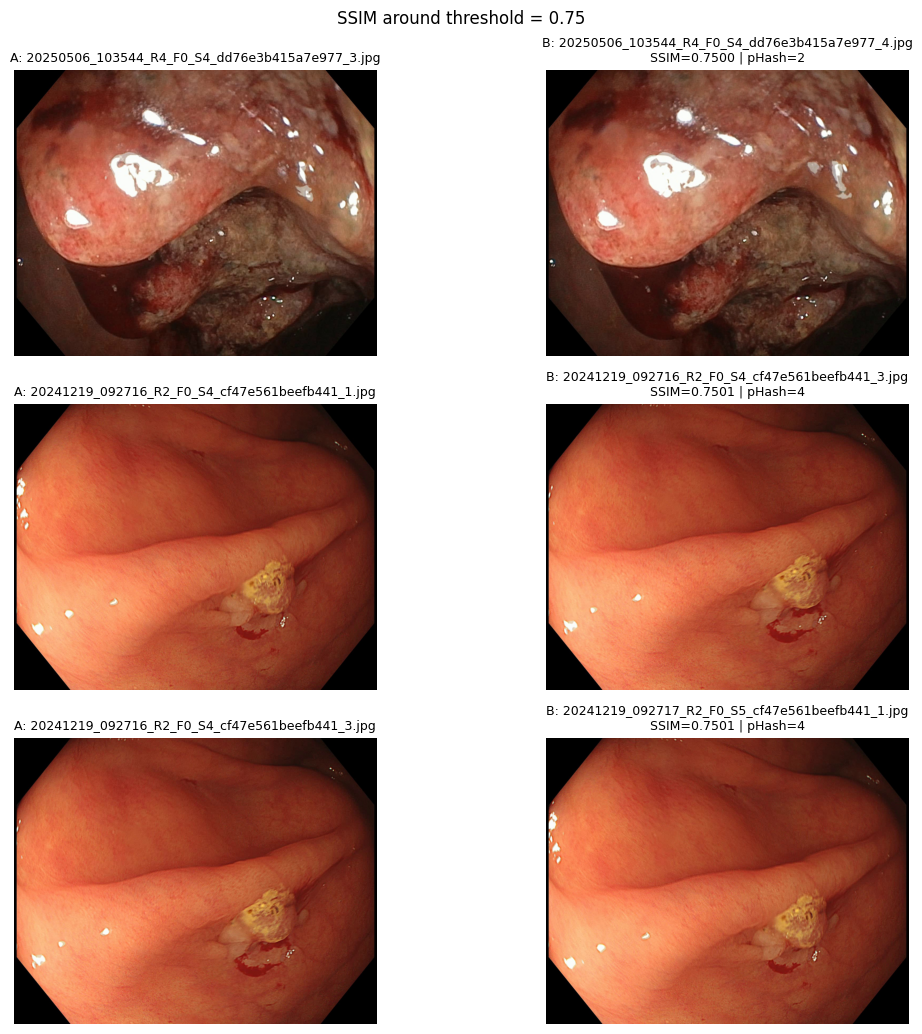

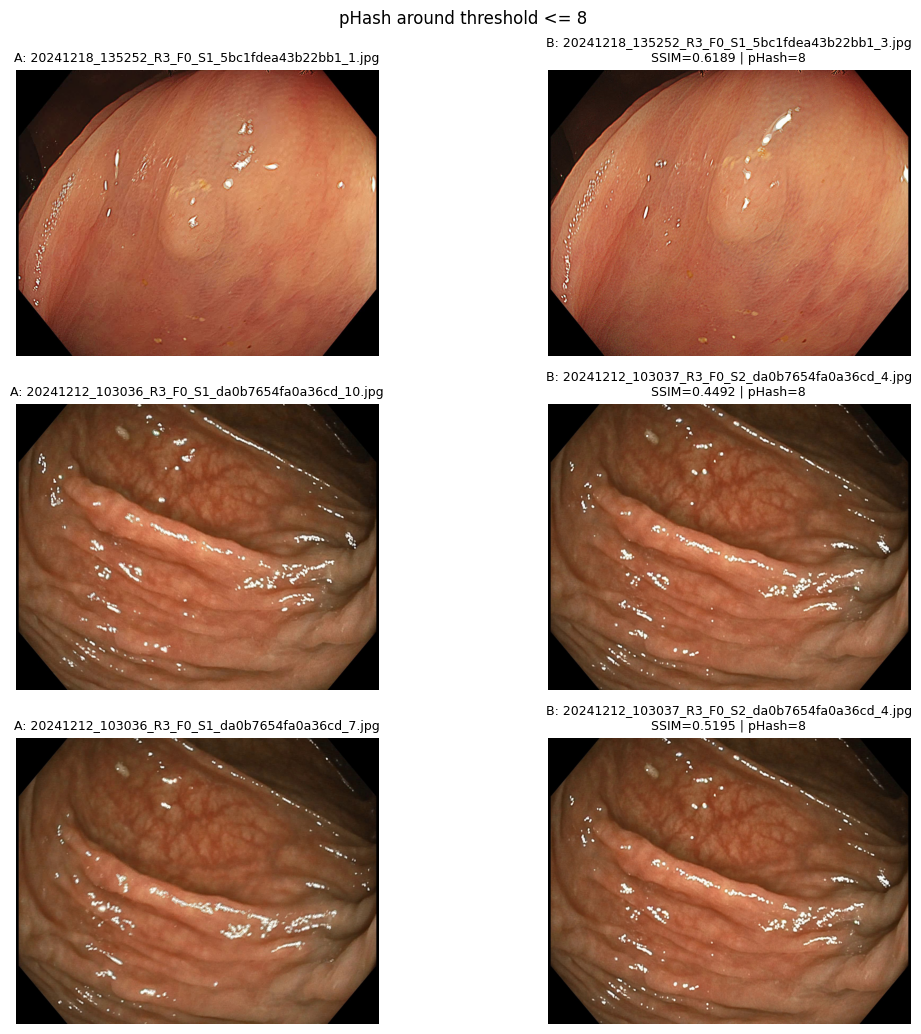

In [6]:
SSIM_THRESHOLDS = [0.70, 0.75, 0.80]
PHASH_DISTANCE_THRESHOLDS = [6, 8, 10]
N_EXAMPLES_PER_THRESHOLD = 3

if similarity_pairs_df.empty:
    print("No comparable pairs found for threshold checks.")
else:
    rows = []
    for threshold in SSIM_THRESHOLDS:
        redundant_mask = similarity_pairs_df["ssim"] >= threshold
        redundant_pair_rows = similarity_pairs_df[redundant_mask]
        images_to_drop = count_images_to_drop_from_pairs(grouped_df, redundant_pair_rows)
        rows.append(
            {
                "ssim_threshold": threshold,
                "redundant_pairs": len(redundant_pair_rows),
                "redundant_pairs_pct": round(
                    100 * len(redundant_pair_rows) / len(similarity_pairs_df),
                    2,
                ),
                "images_to_drop": images_to_drop,
                "images_to_drop_pct": round(100 * images_to_drop / len(grouped_df), 2),
            }
        )
    display(pd.DataFrame(rows))

    rows = []
    for threshold in PHASH_DISTANCE_THRESHOLDS:
        redundant_mask = similarity_pairs_df["phash_distance"] <= threshold
        redundant_pair_rows = similarity_pairs_df[redundant_mask]
        images_to_drop = count_images_to_drop_from_pairs(grouped_df, redundant_pair_rows)
        rows.append(
            {
                "phash_distance_threshold": threshold,
                "redundant_pairs": len(redundant_pair_rows),
                "redundant_pairs_pct": round(
                    100 * len(redundant_pair_rows) / len(similarity_pairs_df),
                    2,
                ),
                "images_to_drop": images_to_drop,
                "images_to_drop_pct": round(100 * images_to_drop / len(grouped_df), 2),
            }
        )
    display(pd.DataFrame(rows))

    for threshold in [0.75]:
        redundant_mask = similarity_pairs_df["ssim"] >= threshold
        examples_df = get_examples_around_threshold(
            dataframe=similarity_pairs_df,
            metric_column="ssim",
            threshold=threshold,
            redundant_mask=redundant_mask,
            n_examples=N_EXAMPLES_PER_THRESHOLD,
        )
        show_pair_examples(
            examples_df,
            images_dir=IMAGES_DIR,
            title=f"SSIM around threshold = {threshold}",
        )

    for threshold in [8]:
        redundant_mask = similarity_pairs_df["phash_distance"] <= threshold
        examples_df = get_examples_around_threshold(
            dataframe=similarity_pairs_df,
            metric_column="phash_distance",
            threshold=threshold,
            redundant_mask=redundant_mask,
            n_examples=N_EXAMPLES_PER_THRESHOLD,
        )
        show_pair_examples(
            examples_df,
            images_dir=IMAGES_DIR,
            title=f"pHash around threshold <= {threshold}",
        )


In [7]:
print("Histology frequency after phase 3 deduplication:")
print(phase3_deduplicated_df["histology"].value_counts())


Histology frequency after phase 3 deduplication:
histology
Adenoma                     2660
Sessile_serrated_adenoma    2330
Hyperplastic                1510
Adenocarcinoma               701
Name: count, dtype: int64


Hardware assigned for tensor computations: cuda
Training metadata: C:\Users\luis\Documents\TFG - Data-Centric AI\data\phase3\phase3_deduplicated_train.csv
Validation metadata: C:\Users\luis\Documents\TFG - Data-Centric AI\data\validation.csv
Train class distribution:
histology
Adenoma                     2660
Sessile_serrated_adenoma    2330
Hyperplastic                1510
Adenocarcinoma               701

Validation class distribution:
histology
Adenoma                     379
Sessile_serrated_adenoma    168
Hyperplastic                 80
Adenocarcinoma               20

Loss weights: {'Adenoma': 0.5196, 'Sessile_serrated_adenoma': 0.5932, 'Hyperplastic': 0.9154, 'Adenocarcinoma': 1.9718}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\phase3_experiment_v3


Training Progress:   2%|▏         | 3/200 [08:56<9:45:59, 178.47s/epoch, Stage=head_only, Train Loss=0.6728, Val Loss=1.2776, Val F1=0.3799 [saved], Smooth F1=0.3728, LR=1.0e-03] 


Switching to full-network fine-tuning at epoch 4.


Training Progress:  28%|██▊       | 56/200 [3:03:31<7:51:54, 196.63s/epoch, Stage=full_network, Train Loss=0.2120, Val Loss=1.4172, Val F1=0.5011, Smooth F1=0.5040, LR=1.0e-06/6.3e-06]        
c:\Users\luis\Documents\TFG - Data-Centric AI\src\ModelTrain.py:876: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where


Early stopping triggered after 12 epochs without improving smoothed macro-F1 or validation loss.

Optimization sequence completed. Selected checkpoint macro-F1: 0.5392 (smoothed: 0.5232) at epoch 45.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\phase3_experiment_v3'.


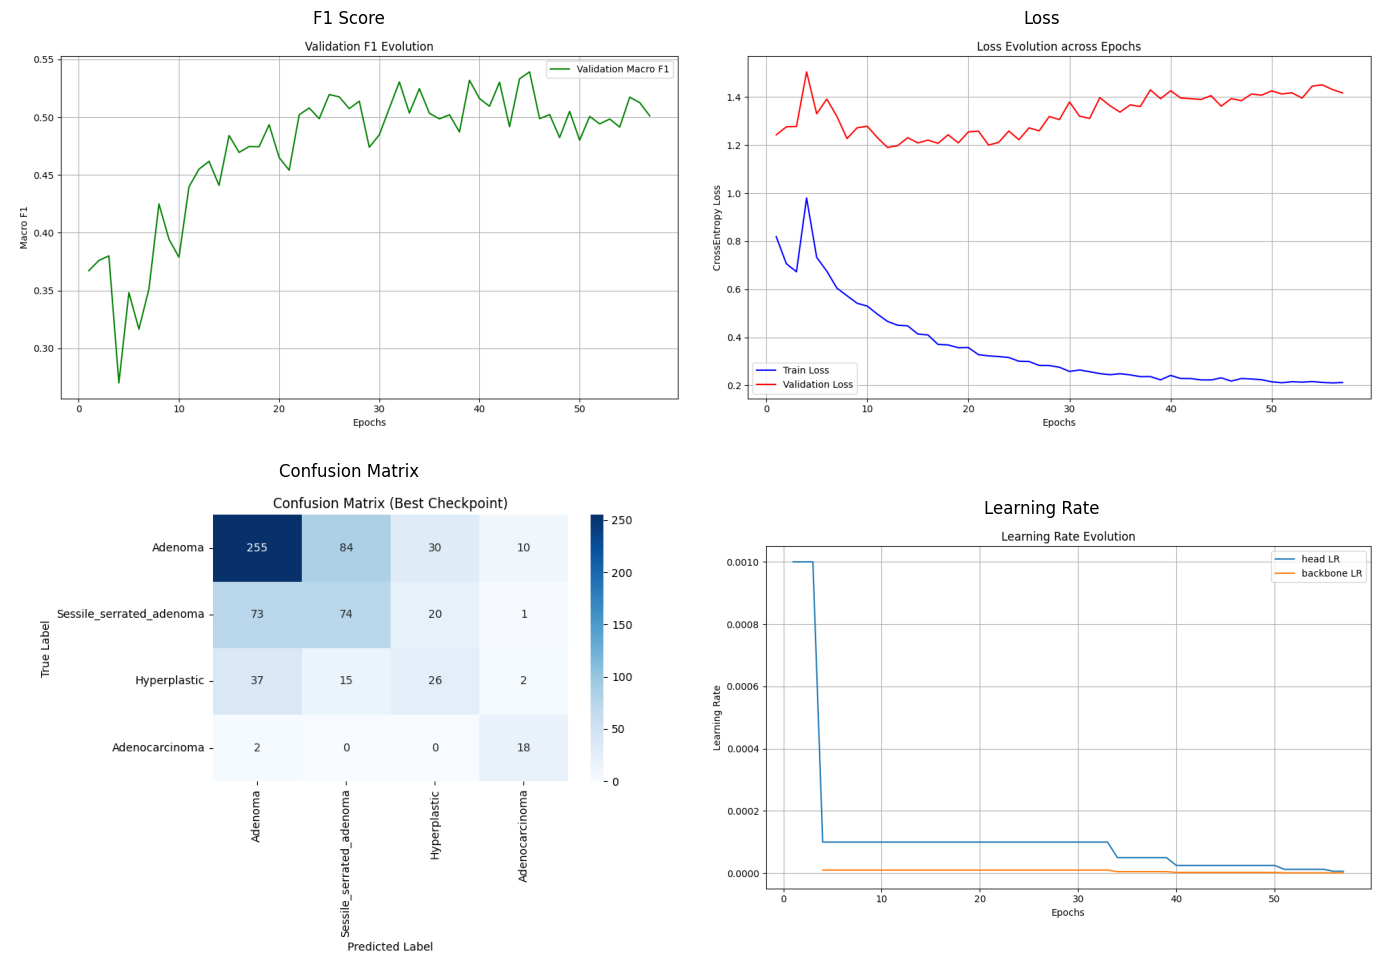

=== GLOBAL METRICS ===
Accuracy:          0.5765
Balanced Accuracy: 0.5846
Macro F1:          0.5392
Weighted F1:       0.5762

=== PER-CLASS METRICS ===
                          precision    recall  f1-score   support

                 Adenoma     0.6948    0.6728    0.6836       379
Sessile_serrated_adenoma     0.4277    0.4405    0.4340       168
            Hyperplastic     0.3421    0.3250    0.3333        80
          Adenocarcinoma     0.5806    0.9000    0.7059        20

                accuracy                         0.5765       647
               macro avg     0.5113    0.5846    0.5392       647
            weighted avg     0.5783    0.5765    0.5762       647



In [9]:
csv_relative_path = Path("phase3/phase3_deduplicated_train.csv")
image_relative_dir = Path("phase2/frames")
validation_csv_dir = VALIDATION_CSV
validation_img_dir = Path("unified_images")
results_dir = Path("phase3_experiment_v3")

plotTrainResults(
    train_csv_dir=csv_relative_path,
    validation_csv_dir=validation_csv_dir,
    train_img_dir=image_relative_dir,
    validation_img_dir=validation_img_dir,
    results_dir=results_dir,
    train=baseline_train,
)
